In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [2]:
N_SPLITS = 5
TEST_SIZE = 0.3 
SEED = 42
SAMPLE_SIZE = 10
TOP_FEATURES = 15

# Hyperparameter grid for XGBClassifier
PARAM_GRID = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5, 7],
    'xgbclassifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'xgbclassifier__min_child_weight': [1, 5, 10],
    'xgbclassifier__gamma': [0.5, 1, 1.5, 2, 5],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0]
}
OUTPUT_DIR = 'output'


In [3]:
def train_test_and_show_results(split_method: str, m_data: dict, plot_roc_and_feature_importances: bool = True, show_fold_results: bool = True,
                                tune_hyperparameters: bool = False, param_grid: dict = None, xgb_params: dict = None, show_label: bool = True):

    # Track results for each fold
    fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_f1_micros, fold_f1_weighted, feature_importances, true_positives, false_positives, true_negatives, false_negatives  = [], [], [], [], [], [], [], [], [], [], [], []

    best_params_per_fold = []  # Track best parameters per fold

    # Store ROC curve points for all folds
    roc_curves = []

    split_0_data = next(iter(m_data.values()))

    feature_names = split_0_data['X_train'].drop(columns=['m_id']).columns  # This will be a pandas.Index
    feature_names = feature_names.str.replace('original_', '', regex=False)

    for fold, split_data in m_data.items():
        print(f"\nFold {fold}:")
        print(f"Original train class distribution: {Counter(split_data['y_train'])}")
        print(f"Original test class distribution: {Counter(split_data['y_test'])}") 
        
        # Check if directory exists
        if not os.path.exists(f"{OUTPUT_DIR}/{split_method}/fold_{fold}"):
            os.makedirs(f"{OUTPUT_DIR}/{split_method}/fold_{fold}")

        # Keep `m_id` for analysis later
        m_id_test = split_data['X_test']['m_id']  # Save `m_id` for test
        day_of_study_test = split_data['X_test']['day_of_study']  # Save `day_of_study` for test

        # Exclude `m_id` and `day_of_study` for training
        X_train = split_data['X_train'].drop(columns=['m_id', 'day_of_study'])
        X_test = split_data['X_test'].drop(columns=['m_id', 'day_of_study'])

        if tune_hyperparameters:

            # Define the model with hyperparameter tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
            ])

            grid_search = GridSearchCV(model, param_grid=param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1_macro', n_jobs=-1)
            grid_search.fit(X_train, split_data['y_train'])
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
            best_params_per_fold.append(best_params)  # Save best parameters
            print(f"Best parameters for fold {fold}: {best_params}")
        else:
            # Use provided xgb_params or default parameters if not tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(**(xgb_params or {}), random_state=SEED)),
            ])
            
            model.fit(X_train, split_data['y_train'])
            best_model = model        

        # Extract feature importances from XGBoost
        xgb_model = best_model.named_steps['xgbclassifier']
        importances = xgb_model.feature_importances_

        # Evaluate on the test set
        preds = best_model.predict(X_test)
        preds_proba = best_model.predict_proba(X_test)[:, 1]  # Probability for the positive class
        
        # Calculate metrics
        accuracy = accuracy_score(split_data['y_test'], preds)
        f1_macro = f1_score(split_data['y_test'], preds, average='macro')
        f1_micro = f1_score(split_data['y_test'], preds, average='micro')
        f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
        precision = precision_score(split_data['y_test'], preds)
        recall = recall_score(split_data['y_test'], preds)

        fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
        roc_auc = auc(fpr, tpr)

        # If auc is NaN, set to 0
        if np.isnan(roc_auc):
            roc_auc = 0
        
        roc_curves.append((fpr, tpr))

        # Calculate the confusion matrix
        cm = confusion_matrix(split_data['y_test'], preds)

        # Handle cases where the confusion matrix shape is unexpected
        if cm.shape == (1, 1):  # Only one class present
            tn, fp, fn, tp = (cm[0, 0], 0, 0, 0) if split_data['y_test'].iloc[0] == 0 else (0, 0, 0, cm[0, 0])
        elif cm.shape == (1, 2):  # One class is missing in y_test
            tn, fp, fn, tp = (cm[0, 0], cm[0, 1], 0, 0)
        elif cm.shape == (2, 1):  # One class is missing in preds
            tn, fp, fn, tp = (0, 0, cm[1, 0], cm[0, 0])
        else:  # Normal case with both classes present
            tn  , fp, fn, tp = cm.ravel()

         # Identify misclassified instances
        misclassified_mask = split_data['y_test'] != preds
        misclassified = pd.DataFrame({
            'm_id': m_id_test[misclassified_mask],
            'day_of_study': day_of_study_test[misclassified_mask],
            'true_label': split_data['y_test'][misclassified_mask],
            'predicted_label': preds[misclassified_mask]
        })
        # Save misclassified instances for this fold
        misclassified.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/misclassified.csv", index=False)

        if show_fold_results:
            # Print fold results
            print(f"\n\nFold {fold} results:")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1-macro: {f1_macro:.4f}")
            print(f"F1-micro: {f1_micro:.4f}")
            print(f"F1-weighted: {f1_weighted:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"ROC AUC: {roc_auc:.4f}")
            print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
            print(f"Classification report:\n{classification_report(split_data['y_test'], preds)}")

        if show_fold_results:
            print(f"Misclassified instances in fold {fold}:")
            print(misclassified[['m_id', 'day_of_study', 'true_label', 'predicted_label']].head())

            print("-" * 50)
        
        # Plot top k features for this fold
        # top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
        # top_importances = importances[top_indices]

        # plt.figure(figsize=(10, 3))
        # plt.subplot(1, 2, 1)
        # plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
        # plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
        # plt.ylabel("Feature Index")
        # plt.xlabel("Importance")
        # plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
        # # Plot confusion matrix
        # plt.subplot(1, 2, 2)
        # cm = confusion_matrix(split_data['y_test'], preds)
        # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        # plt.title(f'Confusion Matrix (Fold {fold})')
        # plt.xlabel('Predicted Label')
        # plt.ylabel('True Label')
        # plt.tight_layout()
        # plt.show()

        # Track results
        fold_accuracies.append(accuracy)
        fold_f1_macros.append(f1_macro)
        fold_f1_micros.append(f1_micro)
        fold_f1_weighted.append(f1_weighted)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_roc_aucs.append(roc_auc)
        feature_importances.append(importances)
        true_positives.append(tp)
        false_negatives.append(fn)
        false_positives.append(fp)
        true_negatives.append(tn)

        # Save fold metrics to a CSV file
        fold_metrics = pd.DataFrame({
            'accuracy': [accuracy],
            'f1_macro': [f1_macro],
            'f1_micro': [f1_micro],
            'f1_weighted': [f1_weighted],
            'precision': [precision],
            'recall': [recall],
            'roc_auc': [roc_auc],
            'true_positives': [tp],
            'false_negatives': [fn],
            'false_positives': [fp],
            'true_negatives': [tn]
        })

        fold_metrics.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/metrics.csv", index=False)

        # Save top 15 feature importances to a csv file
        top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
        top_importances = importances[top_indices]
        top_features = pd.DataFrame({
            'feature': feature_names[top_indices],
            'importance': top_importances
        })

        top_features.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/top_features.csv", index=False)

    print(f"\nAll Folds Completed.") 
    print("\n--------------------------------------------------")
    print("\nSummary of Results:\n")

    # Display best parameters summary
    if tune_hyperparameters:
        print("\nBest parameters per fold:")
        for fold, params in enumerate(best_params_per_fold):
            print(f"Fold {fold}: {params}")

    # Calculate mean importances across folds
    mean_importances = np.mean(feature_importances, axis=0)
    # Get indices of the top k features by mean
    top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
    top_importances_mean = mean_importances[top_indices_mean]
    
    if plot_roc_and_feature_importances:

        # Plotting ROC curve side by side
        plt.figure(figsize=(15, 5))

        # ROC Curve Plot
        plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
        if show_label:
            for i, (fpr, tpr) in enumerate(roc_curves):
                plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
        else:
            for i, (fpr, tpr) in enumerate(roc_curves):
                plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
        plt.title("ROC Curve Across Folds")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")

        plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
        plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
        plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
        plt.ylabel("Feature Index")
        plt.xlabel("Importance")
        plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

        # Display the plots side by side
        plt.tight_layout()  # Adjust layout for better spacing
        plt.show()

    # Display summary statistics across folds
    print(f"\nSummary Across Folds:")
    print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
    print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
    print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
    print(f"Mean precision: {np.mean(fold_precisions):.4f}")
    print(f"Mean recall: {np.mean(fold_recalls):.4f}")
    print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")

    # Standard deviation, variance, coefficient of variation and dispersion index of f1_macro
    print(f"\nStandard Deviation of F1-macro: {np.std(fold_f1_macros):.4f}")
    print(f"Variance of F1-macro: {np.var(fold_f1_macros):.4f}")
    print(f"Coefficient of Variation of F1-macro: {np.std(fold_f1_macros) / np.mean(fold_f1_macros):.4f}")
    print(f"Dispersion Index of F1-macro: {np.var(fold_f1_macros) / np.mean(fold_f1_macros):.4f}")

    print("\n--------------------------------------------------")

    # Save summary statistics to a CSV file
    summary_metrics = pd.DataFrame({
        'accuracy': [np.mean(fold_accuracies)],
        'f1_macro': [np.mean(fold_f1_macros)],
        'f1_micro': [np.mean(fold_f1_micros)],
        'f1_weighted': [np.mean(fold_f1_weighted)],
        'precision': [np.mean(fold_precisions)],
        'recall': [np.mean(fold_recalls)],
        'roc_auc': [np.mean(fold_roc_aucs)],
        'std_f1_macro': [np.std(fold_f1_macros)],
        'var_f1_macro': [np.var(fold_f1_macros)],
        'cv_f1_macro': [np.std(fold_f1_macros) / np.mean(fold_f1_macros)],
        'di_f1_macro': [np.var(fold_f1_macros) / np.mean(fold_f1_macros)]
    })

    summary_metrics.to_csv(f"{OUTPUT_DIR}/{split_method}/summary_metrics.csv", index=False)

    # Save top feature importances and split method in a csv file
    top_features = pd.DataFrame({
        'feature': feature_names[top_indices_mean],
        'importance': top_importances_mean
    })

    top_features.to_csv(f"{OUTPUT_DIR}/{split_method}/top_features.csv", index=False) 

    # Optional: Calculate the most common parameters across folds
    if tune_hyperparameters:
        most_comon_params = max(set(best_params_per_fold), key=best_params_per_fold.count)
        print("\nMost common parameters across folds:")
        print(most_comon_params)

In [4]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
df = dataclass.df


Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})


Fold 0 results:
Accuracy: 0.8158
F1-macro: 0.5589
F1-micro: 0.8158
F1-weighted: 0.7626
Precision: 0.6667
Recall: 0.1333
ROC AUC: 0.7475
True Positives: 2, False Negatives: 13, False Positives: 1, True Negatives: 60
Classification report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.67      0.13      0.22        15

    accuracy                           0.82        76
   macro avg       0.74      0.56      0.56        76
weighted avg       0.79      0.82      0.76        76

Misclassified instances in fold 0:
    m_id  day_of_study  true_label  predicted_label
0   1281            17           1                0
1   1285            17           1                0
5   1382            17           1                0
11  1285            17           1                0
17  1276    

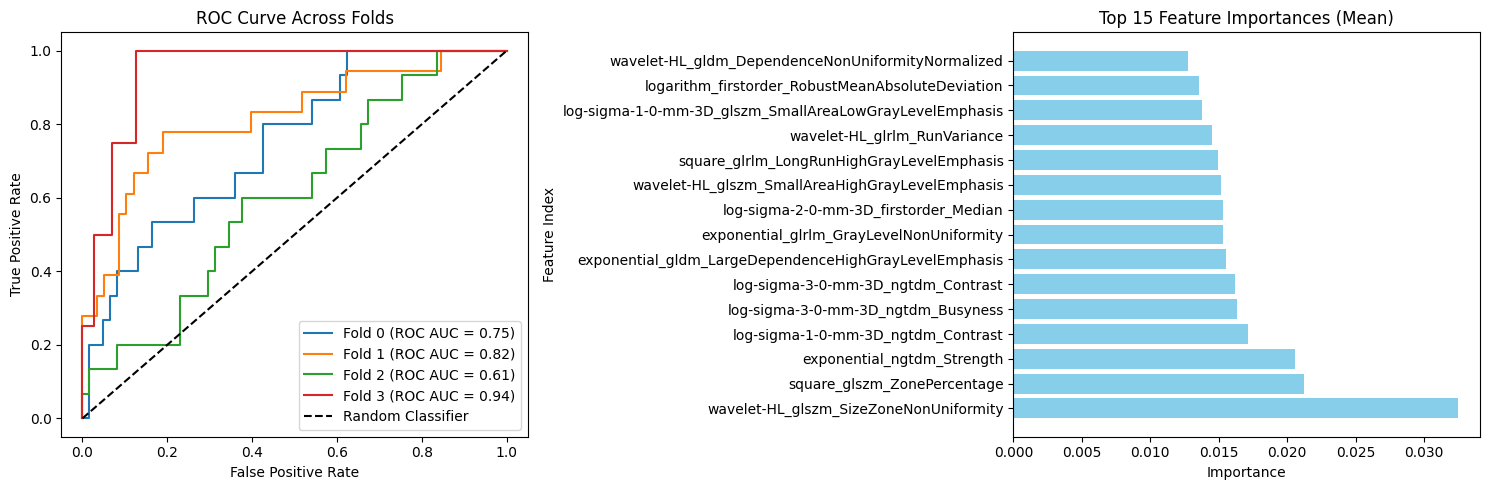


Summary Across Folds:
Mean accuracy: 0.8059
Mean F1-macro: 0.6205
Mean F1-micro: 0.8059
Mean F1-weighted: 0.7960
Mean precision: 0.4559
Mean recall: 0.3611
Mean ROC AUC: 0.7786

Standard Deviation of F1-macro: 0.1055
Variance of F1-macro: 0.0111
Coefficient of Variation of F1-macro: 0.1701
Dispersion Index of F1-macro: 0.0180

--------------------------------------------------


In [5]:
split_method, m_data = DataSplitting.expanding_window_split(df, 4)

#train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params= {'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
})

In [6]:
xgb_params = {
 'xgbclassifier__colsample_bytree': 0.6,
 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
}

Split 0: Train=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113], Test=[114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151]
Split 1: Train=[76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 

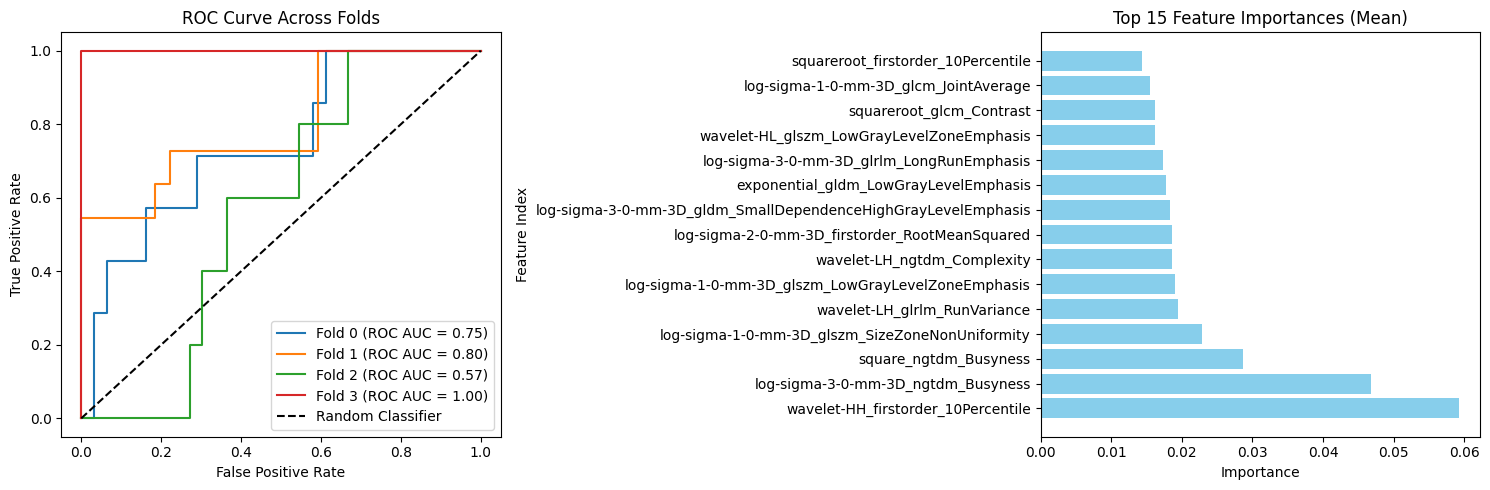


Summary Across Folds:
Mean accuracy: 0.8092
Mean F1-macro: 0.6541
Mean F1-micro: 0.8092
Mean F1-weighted: 0.8061
Mean precision: 0.5114
Mean recall: 0.3745
Mean ROC AUC: 0.7794

Standard Deviation of F1-macro: 0.1699
Variance of F1-macro: 0.0288
Coefficient of Variation of F1-macro: 0.2597
Dispersion Index of F1-macro: 0.0441

--------------------------------------------------


In [7]:
split_method, m_data = DataSplitting.rolling_window_split(
    df, 
    n_splits=4, 
    train_pct=0.3, 
    test_pct=0.1
)

#train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, 
                            xgb_params= {
                                'xgbclassifier__colsample_bytree': 0.6, 
                                'xgbclassifier__gamma': 0.5,
                                'xgbclassifier__learning_rate': 0.01,
                                'xgbclassifier__max_depth': 3,
                                'xgbclassifier__min_child_weight': 1,
                                'xgbclassifier__n_estimators': 100,
                                'xgbclassifier__subsample': 0.6
                            }
)

Total groups: 18, Test groups: 5

Fold 0:
Original train class distribution: Counter({0: 309, 1: 50})
Original test class distribution: Counter({1: 16, 0: 7})


Fold 0 results:
Accuracy: 0.5217
F1-macro: 0.5181
F1-micro: 0.5217
F1-weighted: 0.5017
Precision: 1.0000
Recall: 0.3125
ROC AUC: 0.8661
True Positives: 5, False Negatives: 11, False Positives: 0, True Negatives: 7
Classification report:
              precision    recall  f1-score   support

           0       0.39      1.00      0.56         7
           1       1.00      0.31      0.48        16

    accuracy                           0.52        23
   macro avg       0.69      0.66      0.52        23
weighted avg       0.81      0.52      0.50        23

Misclassified instances in fold 0:
    m_id  day_of_study  true_label  predicted_label
0   1276            19           1                0
3   1276            23           1                0
10  1276            25           1                0
14  1276            29          

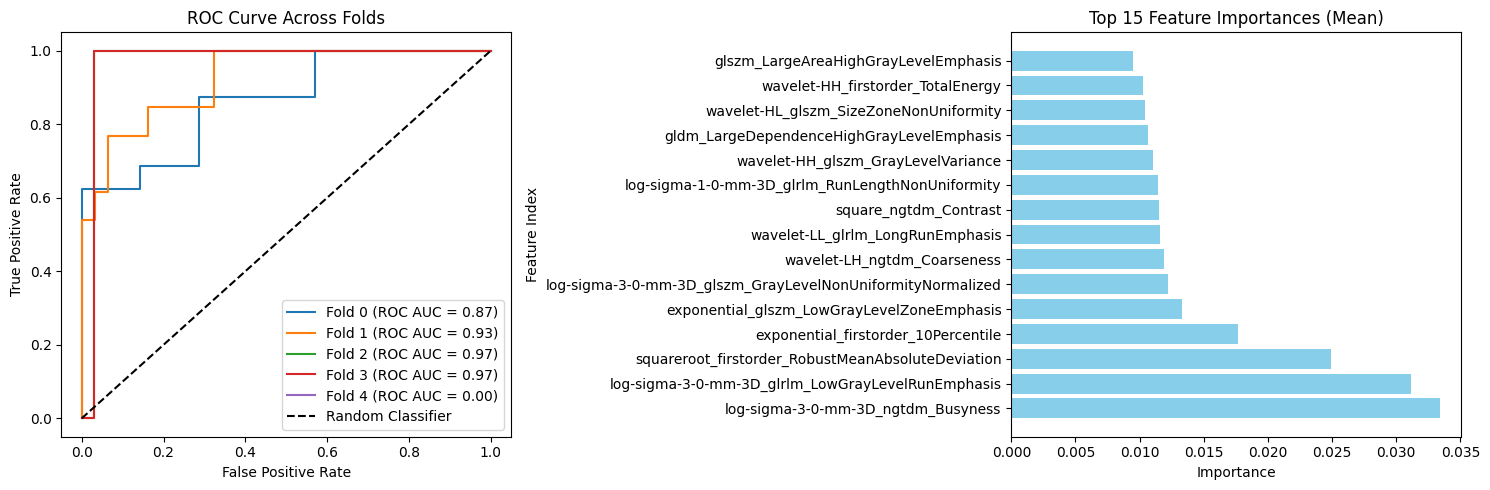


Summary Across Folds:
Mean accuracy: 0.8327
Mean F1-macro: 0.7215
Mean F1-micro: 0.8327
Mean F1-weighted: 0.8325
Mean precision: 0.5067
Mean recall: 0.5394
Mean ROC AUC: 0.7462

Standard Deviation of F1-macro: 0.1592
Variance of F1-macro: 0.0253
Coefficient of Variation of F1-macro: 0.2206
Dispersion Index of F1-macro: 0.0351

--------------------------------------------------


In [8]:
split_method, m_data = DataSplitting.split_data_population_informed(df=df, seed=SEED, n_splits=N_SPLITS, test_size=TEST_SIZE)

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params)



Fold 0:
Original train class distribution: Counter({0: 111, 1: 26})
Original test class distribution: Counter({0: 41, 1: 8})


Fold 0 results:
Accuracy: 0.8163
F1-macro: 0.6458
F1-micro: 0.8163
F1-weighted: 0.8113
Precision: 0.4286
Recall: 0.3750
ROC AUC: 0.6280
True Positives: 3, False Negatives: 5, False Positives: 4, True Negatives: 37
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        41
           1       0.43      0.38      0.40         8

    accuracy                           0.82        49
   macro avg       0.65      0.64      0.65        49
weighted avg       0.81      0.82      0.81        49

Misclassified instances in fold 0:
    m_id  day_of_study  true_label  predicted_label
4   1261            22           0                1
10  1263            25           0                1
16  1264            23           0                1
25  1276            23           1                0
26  1276     

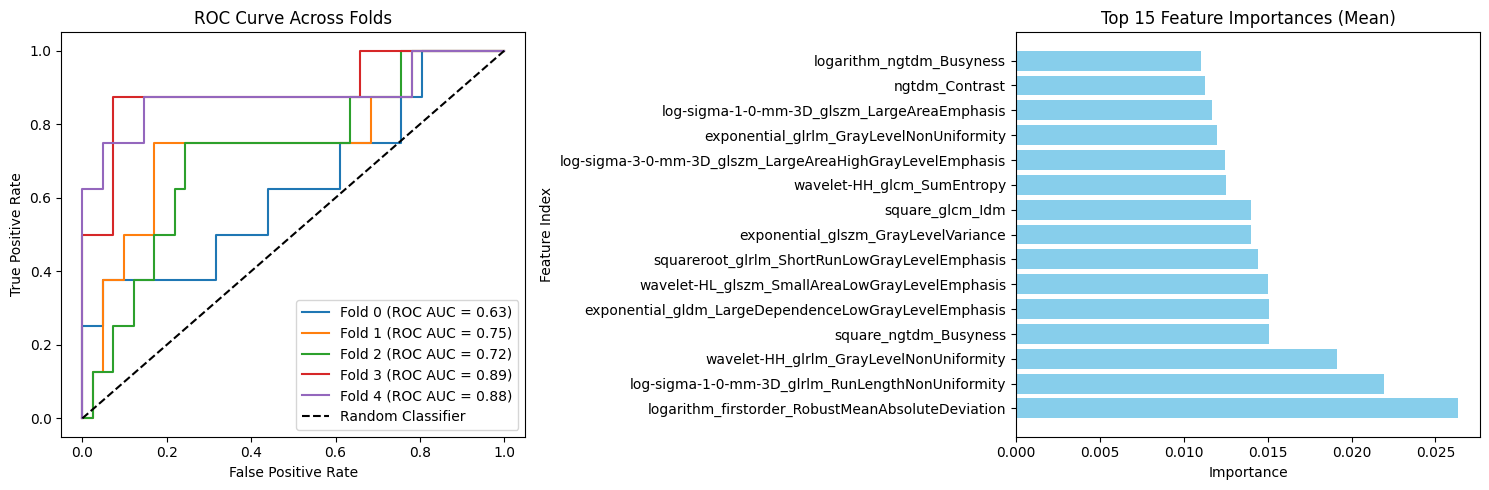


Summary Across Folds:
Mean accuracy: 0.8367
Mean F1-macro: 0.5998
Mean F1-micro: 0.8367
Mean F1-weighted: 0.8061
Mean precision: 0.5657
Mean recall: 0.2500
Mean ROC AUC: 0.7726

Standard Deviation of F1-macro: 0.0796
Variance of F1-macro: 0.0063
Coefficient of Variation of F1-macro: 0.1327
Dispersion Index of F1-macro: 0.0106

--------------------------------------------------


In [9]:
split_method, m_data = DataSplitting.expanding_window_split_by_mice_group(df=df, n_splits=N_SPLITS)

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params)

In [11]:
split_method, m_data = DataSplitting.grouped_combinations_split_with_sampling(df=df, n_splits=N_SPLITS, sample_size=816, seed=SEED)
print(f"Generated {len(m_data)} sampled combinations.")

train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params=xgb_params, show_label=False, plot_roc_and_feature_importances=False, show_fold_results=False)

Total possible combinations: 816
Generated 816 sampled combinations.

Fold 0:
Original train class distribution: Counter({0: 304, 1: 37})
Original test class distribution: Counter({1: 29, 0: 12})

Fold 1:
Original train class distribution: Counter({0: 264, 1: 58})
Original test class distribution: Counter({0: 52, 1: 8})

Fold 2:
Original train class distribution: Counter({0: 288, 1: 58})
Original test class distribution: Counter({0: 28, 1: 8})

Fold 3:
Original train class distribution: Counter({0: 226, 1: 54})
Original test class distribution: Counter({0: 90, 1: 12})

Fold 4:
Original train class distribution: Counter({0: 248, 1: 66})
Original test class distribution: Counter({0: 68})

Fold 5:
Original train class distribution: Counter({0: 214, 1: 66})
Original test class distribution: Counter({0: 102})

Fold 6:
Original train class distribution: Counter({0: 300, 1: 41})
Original test class distribution: Counter({1: 25, 0: 16})

Fold 7:
Original train class distribution: Counter({0: 2

UnboundLocalError: cannot access local variable 'top_indices_mean' where it is not associated with a value

In [ ]:
# Check if directory exists
if not os.path.exists(f"{OUTPUT_DIR}/top_features"):
    os.makedirs(f"{OUTPUT_DIR}/top_features")



In [11]:
# Import necessary library
import pandas as pd

# Define the feature importance lists for each split
feature_importances = {
    "grouped_combinations_split_with_sampling": {
        "exponential_glszm_SizeZoneNonUniformity": 0.0293,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0241,
        "exponential_gldm_GrayLevelNonUniformity": 0.0178,
        "exponential_glrlm_GrayLevelNonUniformity": 0.0166,
        "log-sigma-3-0-mm-3D_glrlm_RunEntropy": 0.0117,
        "wavelet-HL_glszm_ZoneEntropy": 0.0107,
        "squareroot_firstorder_Median": 0.0103,
        "log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis": 0.0100,
        "square_firstorder_Median": 0.0093,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0092,
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0089,
        "day_of_study": 0.0088,
        "log-sigma-3-0-mm-3D_glszm_ZoneEntropy": 0.0087,
        "squareroot_firstorder_RootMeanSquared": 0.0082,
        "wavelet-HH_glcm_SumSquares": 0.0073,
    },
    "expanding_window_split": {
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0232,
        "square_glszm_ZoneVariance": 0.0222,
        "logarithm_firstorder_RootMeanSquared": 0.0212,
        "gldm_LargeDependenceLowGrayLevelEmphasis": 0.0189,
        "log-sigma-1-0-mm-3D_ngtdm_Strength": 0.0182,
        "square_ngtdm_Strength": 0.0177,
        "gradient_firstorder_10Percentile": 0.0174,
        "log-sigma-3-0-mm-3D_ngtdm_Strength": 0.0172,
        "log-sigma-2-0-mm-3D_firstorder_Minimum": 0.0171,
        "exponential_gldm_LargeDependenceLowGrayLevelEmphasis": 0.0163,
        "wavelet-HL_glszm_SmallAreaLowGrayLevelEmphasis": 0.0160,
        "wavelet-HL_glrlm_ShortRunEmphasis": 0.0155,
        "wavelet-LH_glrlm_ShortRunEmphasis": 0.0150,
        "log-sigma-2-0-mm-3D_glszm_ZoneEntropy": 0.0129,
        "wavelet-HL_gldm_DependenceVariance": 0.0129,
    },
    "split_data_population_informed": {
        "exponential_gldm_GrayLevelNonUniformity": 0.0417,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0411,
        "square_ngtdm_Strength": 0.0322,
        "squareroot_firstorder_RootMeanSquared": 0.0268,
        "wavelet-HL_glszm_SizeZoneNonUniformityNormalized": 0.0212,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0207,
        "squareroot_firstorder_90Percentile": 0.0180,
        "wavelet-LL_ngtdm_Coarseness": 0.0144,
        "wavelet-HH_firstorder_Entropy": 0.0141,
        "squareroot_glrlm_ShortRunHighGrayLevelEmphasis": 0.0124,
        "log-sigma-3-0-mm-3D_glszm_GrayLevelVariance": 0.0116,
        "gldm_LargeDependenceLowGrayLevelEmphasis": 0.0111,
        "day_of_study": 0.0110,
        "wavelet-HH_gldm_SmallDependenceLowGrayLevelEmphasis": 0.0105,
        "log-sigma-3-0-mm-3D_glrlm_RunEntropy": 0.0104,
    },
    "expanding_window_split_by_mice_group": {
        "square_ngtdm_Strength": 0.0335,
        "log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized": 0.0315,
        "log-sigma-3-0-mm-3D_ngtdm_Complexity": 0.0266,
        "squareroot_firstorder_RootMeanSquared": 0.0236,
        "ngtdm_Strength": 0.0204,
        "log-sigma-3-0-mm-3D_glrlm_HighGrayLevelRunEmphasis": 0.0202,
        "square_ngtdm_Coarseness": 0.0168,
        "exponential_glszm_SmallAreaLowGrayLevelEmphasis": 0.0140,
        "wavelet-HH_glcm_SumSquares": 0.0132,
        "log-sigma-3-0-mm-3D_ngtdm_Coarseness": 0.0130,
        "wavelet-LL_glrlm_LongRunLowGrayLevelEmphasis": 0.0128,
        "logarithm_glszm_LargeAreaHighGrayLevelEmphasis": 0.0125,
        "log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis": 0.0120,
        "log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized": 0.0109,
        "square_glcm_Idmn": 0.0103,
    },
}

# Combine all feature importance values into a single DataFrame
all_features = []
for split_name, features in feature_importances.items():
    for feature, importance in features.items():
        all_features.append({"Feature": feature, "Importance": importance, "Split": split_name})

# Create DataFrame and calculate mean importance for each feature
df = pd.DataFrame(all_features)
mean_importances = df.groupby("Feature")["Importance"].mean().reset_index()

# Sort features by mean importance in descending order
sorted_features = mean_importances.sort_values(by="Importance", ascending=False)

# Save the sorted features to a CSV file
sorted_features.to_csv("sorted_features.csv", index=False)
